#  Mini Project 3: Real-Time Weather API Data Analysis

---

# Step 1: Setup — Import Libraries

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'Analysis Date: {datetime.now().strftime("%B %d, %Y %H:%M")}')

Libraries imported successfully!
Analysis Date: April 21, 2026 19:20


## Step 2: API Configuration
> **Get your FREE API key:** Go to https://openweathermap.org/api → Sign Up → API Keys tab

In [2]:
API_KEY = "68523ba8e040df0b09351b021a1a403d"
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

# 10 Major Indian Cities
CITIES = [
    "Bengaluru", "Mumbai", "Delhi", "Chennai",
    "Kolkata", "Hyderabad", "Pune", "Ahmedabad",
    "Jaipur", "Lucknow"
]

print(f'Target Cities: {len(CITIES)}')
print(f' {" | ".join(CITIES)}')

Target Cities: 10
 Bengaluru | Mumbai | Delhi | Chennai | Kolkata | Hyderabad | Pune | Ahmedabad | Jaipur | Lucknow


## Step 3: Fetch Live Weather Data from API

In [3]:
def fetch_weather(city, api_key):
    """Fetch weather data for a single city."""
    params = {
        'q': f'{city},IN',
        'appid': api_key,
        'units': 'metric'  # Celsius
    }
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        return {
            'City': city,
            'Temperature (°C)': data['main']['temp'],
            'Feels Like (°C)': data['main']['feels_like'],
            'Min Temp (°C)': data['main']['temp_min'],
            'Max Temp (°C)': data['main']['temp_max'],
            'Humidity (%)': data['main']['humidity'],
            'Pressure (hPa)': data['main']['pressure'],
            'Wind Speed (m/s)': data['wind']['speed'],
            'Wind Direction (°)': data['wind'].get('deg', 0),
            'Visibility (km)': data.get('visibility', 0) / 1000,
            'Cloudiness (%)': data['clouds']['all'],
            'Weather': data['weather'][0]['main'],
            'Description': data['weather'][0]['description'].title(),
            'Sunrise': datetime.fromtimestamp(data['sys']['sunrise']).strftime('%H:%M'),
            'Sunset': datetime.fromtimestamp(data['sys']['sunset']).strftime('%H:%M'),
            'Fetched At': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
    except requests.exceptions.RequestException as e:
        print(f' Error fetching {city}: {e}')
        return None

# Fetch data for all cities
print(' Fetching weather data...\n')
weather_records = []

for city in CITIES:
    record = fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(f' {city:15} — {record["Temperature (°C)"]}°C, {record["Humidity (%)"]:.0f}% humidity, {record["Description"]}')

print(f'\n Successfully fetched data for {len(weather_records)}/{len(CITIES)} cities!')

 Fetching weather data...

 Bengaluru       — 32.24°C, 29% humidity, Few Clouds
 Mumbai          — 31.99°C, 55% humidity, Smoke
 Delhi           — 34.05°C, 22% humidity, Clear Sky
 Chennai         — 30.41°C, 80% humidity, Few Clouds
 Kolkata         — 30.97°C, 79% humidity, Haze
 Hyderabad       — 31.23°C, 35% humidity, Haze
 Pune            — 34.52°C, 99% humidity, Few Clouds
 Ahmedabad       — 36.02°C, 11% humidity, Smoke
 Jaipur          — 35.62°C, 16% humidity, Haze
 Lucknow         — 34.99°C, 17% humidity, Haze

 Successfully fetched data for 10/10 cities!


## Step 4: Store in DataFrame

In [4]:
df = pd.DataFrame(weather_records)

print('DATAFRAME OVERVIEW')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df

DATAFRAME OVERVIEW
Shape: 10 rows × 16 columns

Columns: ['City', 'Temperature (°C)', 'Feels Like (°C)', 'Min Temp (°C)', 'Max Temp (°C)', 'Humidity (%)', 'Pressure (hPa)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Visibility (km)', 'Cloudiness (%)', 'Weather', 'Description', 'Sunrise', 'Sunset', 'Fetched At']


,City,Temperature (°C),Feels Like (°C),Min Temp (°C),Max Temp (°C),Humidity (%),Pressure (hPa),Wind Speed (m/s),Wind Direction (°),Visibility (km),Cloudiness (%),Weather,Description,Sunrise,Sunset,Fetched At
0,Bengaluru,32.24,30.97,30.90,33.45,29,1007,6.71,113,6.0,20,Clouds,Few Clouds,06:03,18:32,2026-04-21 19:20:19
1,Mumbai,31.99,35.62,31.99,31.99,55,1007,6.17,320,4.5,4,Smoke,Smoke,06:17,18:57,2026-04-21 19:20:19
2,Delhi,34.05,32.22,34.05,34.05,22,1002,3.60,270,6.0,0,Clear,Clear Sky,05:49,18:49,2026-04-21 19:20:19
3,Chennai,30.41,37.41,30.00,30.99,80,1007,6.17,150,6.0,20,Clouds,Few Clouds,05:52,18:22,2026-04-21 19:20:20
4,Kolkata,30.97,37.97,30.97,30.97,79,1003,7.20,150,4.0,20,Haze,Haze,05:11,17:58,2026-04-21 19:20:20
5,Hyderabad,31.23,30.53,28.73,31.23,35,1006,4.12,200,5.0,75,Haze,Haze,05:56,18:33,2026-04-21 19:20:21
6,Pune,34.52,41.52,34.52,34.67,99,1007,0.89,265,10.0,20,Clouds,Few Clouds,06:13,18:52,2026-04-21 19:20:21
7,Ahmedabad,36.02,33.30,36.02,36.02,11,1006,3.09,230,4.0,9,Smoke,Smoke,06:14,19:02,2026-04-21 19:20:22
8,Jaipur,35.62,33.29,35.62,35.62,16,1005,3.60,280,5.0,20,Haze,Haze,05:57,18:53,2026-04-21 19:20:22
9,Lucknow,34.99,32.73,34.99,34.99,17,1002,3.09,300,4.0,0,Haze,Haze,05:36,18:32,2026-04-21 19:20:23


## Step 5: Data Cleaning & Validation

In [5]:
print('DATA QUALITY CHECK')
print(f'\n Missing Values:')
print(df.isnull().sum())

# Check for outliers using IQR method
print('\n Temperature Range Validation:')
temp_col = 'Temperature (°C)'
Q1 = df[temp_col].quantile(0.25)
Q3 = df[temp_col].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[temp_col] < Q1 - 1.5*IQR) | (df[temp_col] > Q3 + 1.5*IQR)]
print(f'IQR Range: {Q1:.1f}°C – {Q3:.1f}°C')
print(f'Outliers found: {len(outliers)}')

# Add heat index (derived feature)
df['Heat Index'] = df['Temperature (°C)'] + 0.33 * (df['Humidity (%)'] / 100 * 6.105) - 4

# Add comfort category
def classify_comfort(row):
    t = row['Temperature (°C)']
    h = row['Humidity (%)']
    if t < 20: return 'Cool'
    elif t < 28 and h < 60: return 'Comfortable'
    elif t < 32 or h < 70: return 'Warm'
    else: return 'Hot & Humid'

df['Comfort Level'] = df.apply(classify_comfort, axis=1)

print('\n Comfort Level Distribution:')
print(df['Comfort Level'].value_counts())
print('\n Data cleaning complete! 2 new features engineered.')

DATA QUALITY CHECK

 Missing Values:
City                  0
Temperature (°C)      0
Feels Like (°C)       0
Min Temp (°C)         0
Max Temp (°C)         0
Humidity (%)          0
Pressure (hPa)        0
Wind Speed (m/s)      0
Wind Direction (°)    0
Visibility (km)       0
Cloudiness (%)        0
Weather               0
Description           0
Sunrise               0
Sunset                0
Fetched At            0
dtype: int64

 Temperature Range Validation:
IQR Range: 31.4°C – 34.9°C
Outliers found: 0

 Comfort Level Distribution:
Comfort Level
Warm           9
Hot & Humid    1
Name: count, dtype: int64

 Data cleaning complete! 2 new features engineered.


## Step 6: Statistical Summary

In [6]:
numeric_cols = ['Temperature (°C)', 'Feels Like (°C)', 'Humidity (%)',
                'Wind Speed (m/s)', 'Visibility (km)', 'Cloudiness (%)', 'Pressure (hPa)']

print('STATISTICAL SUMMARY')
summary = df[numeric_cols].describe().round(2)
print(summary)

print('\n=== KEY INSIGHTS ===')
hottest = df.loc[df['Temperature (°C)'].idxmax()]
coolest = df.loc[df['Temperature (°C)'].idxmin()]
most_humid = df.loc[df['Humidity (%)'].idxmax()]
windiest = df.loc[df['Wind Speed (m/s)'].idxmax()]

print(f'Hottest City:    {hottest["City"]} ({hottest["Temperature (°C)"]:.1f}°C)')
print(f'Coolest City:    {coolest["City"]} ({coolest["Temperature (°C)"]:.1f}°C)')
print(f'Most Humid:      {most_humid["City"]} ({most_humid["Humidity (%)"]:.0f}%)')
print(f'Windiest City:   {windiest["City"]} ({windiest["Wind Speed (m/s)"]:.1f} m/s)')
print(f'Avg Temperature: {df["Temperature (°C)"].mean():.1f}°C')
print(f'Avg Humidity:    {df["Humidity (%)"].mean():.1f}%')

STATISTICAL SUMMARY
       Temperature (°C)  Feels Like (°C)  Humidity (%)  Wind Speed (m/s)  \
count             10.00            10.00         10.00             10.00   
mean              33.20            34.56         44.30              4.46   
std                2.07             3.50         31.72              2.01   
min               30.41            30.53         11.00              0.89   
25%               31.42            32.35         18.25              3.22   
50%               33.14            33.30         32.00              3.86   
75%               34.87            36.96         73.00              6.17   
max               36.02            41.52         99.00              7.20   

       Visibility (km)  Cloudiness (%)  Pressure (hPa)  
count            10.00           10.00            10.0  
mean              5.45           18.80          1005.2  
std               1.80           21.57             2.1  
min               4.00            0.00          1002.0  
25%       

## Step 7: Visualizations
### Plot 1 — Temperature Comparison Across Cities

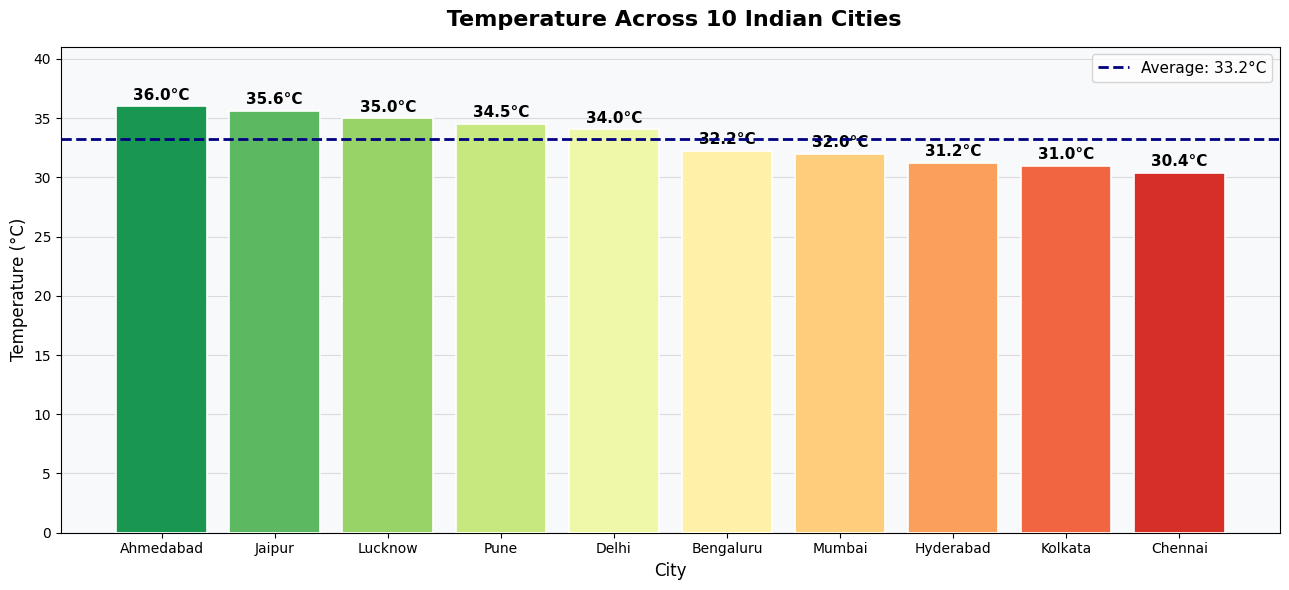

 Plot 1 saved!


In [7]:
df_sorted = df.sort_values('Temperature (°C)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(df_sorted)))
bars = ax.bar(df_sorted['City'], df_sorted['Temperature (°C)'], color=colors, edgecolor='white', linewidth=1.2, zorder=3)

# Add value labels
for bar, val in zip(bars, df_sorted['Temperature (°C)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}°C', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(df['Temperature (°C)'].mean(), color='navy', linewidth=2, linestyle='--', label=f'Average: {df["Temperature (°C)"].mean():.1f}°C', zorder=4)
ax.set_title(' Temperature Across 10 Indian Cities', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_ylim(0, df_sorted['Temperature (°C)'].max() + 5)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot1_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 1 saved!')

### Plot 2 — Temperature vs Feels Like (Perception Gap)

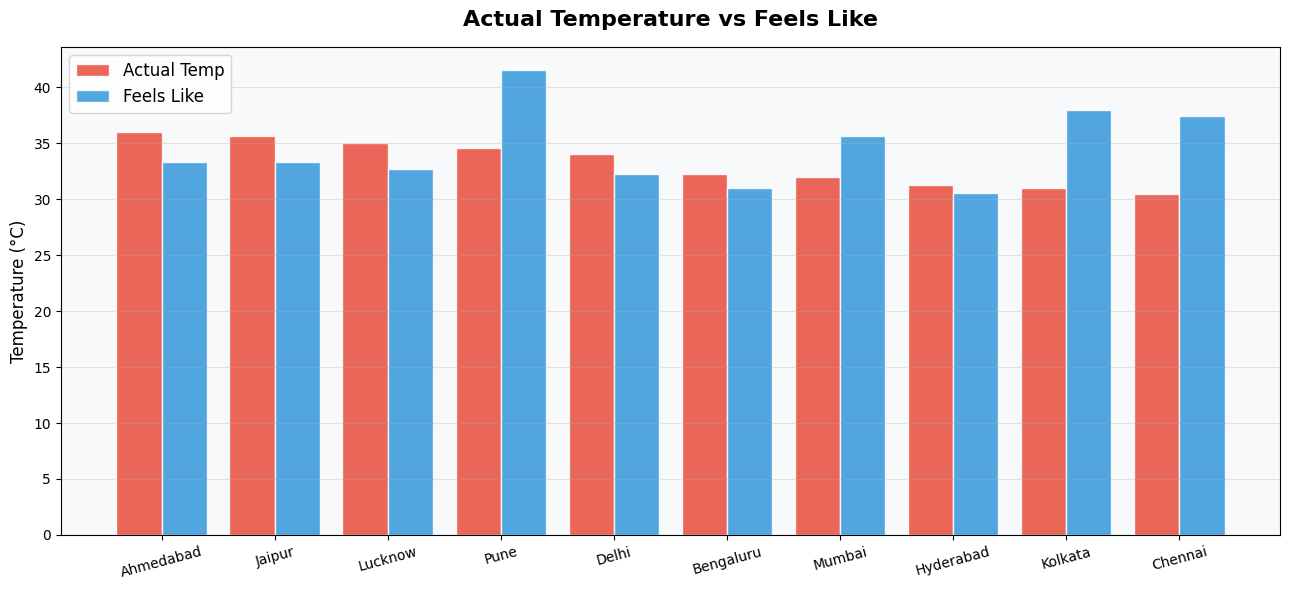

 Plot 2 saved!


In [8]:
x = np.arange(len(df_sorted))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width/2, df_sorted['Temperature (°C)'], width, label='Actual Temp', color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, df_sorted['Feels Like (°C)'], width, label='Feels Like', color='#3498db', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['City'], rotation=15)
ax.set_title('Actual Temperature vs Feels Like', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot2_feelslike.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 2 saved!')

### Plot 3 — Humidity Levels

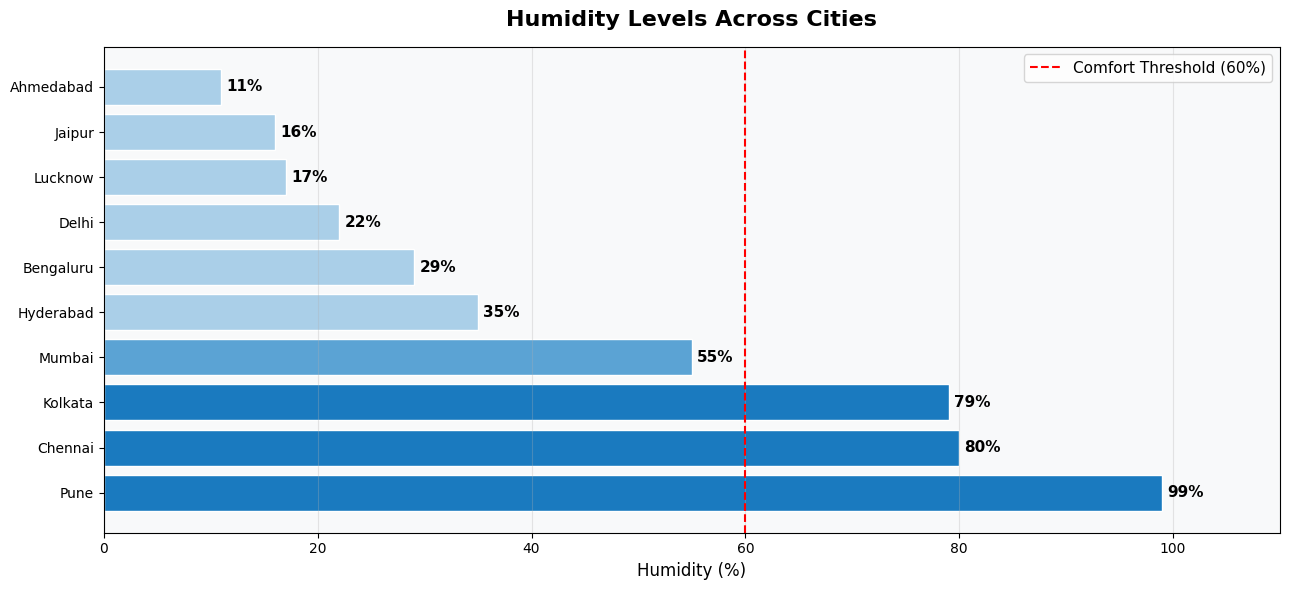

Plot 3 saved!


In [9]:
df_h = df.sort_values('Humidity (%)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors_h = ['#1a7abf' if h > 70 else '#5ba3d4' if h > 50 else '#aacfe8' for h in df_h['Humidity (%)']]
bars = ax.barh(df_h['City'], df_h['Humidity (%)'], color=colors_h, edgecolor='white', linewidth=1)

for bar, val in zip(bars, df_h['Humidity (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=11, fontweight='bold')

ax.axvline(60, color='red', linestyle='--', linewidth=1.5, label='Comfort Threshold (60%)')
ax.set_title('Humidity Levels Across Cities', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Humidity (%)', fontsize=12)
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot3_humidity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 saved!')

### Plot 4 — Temperature vs Humidity Scatter (with Comfort Zones)

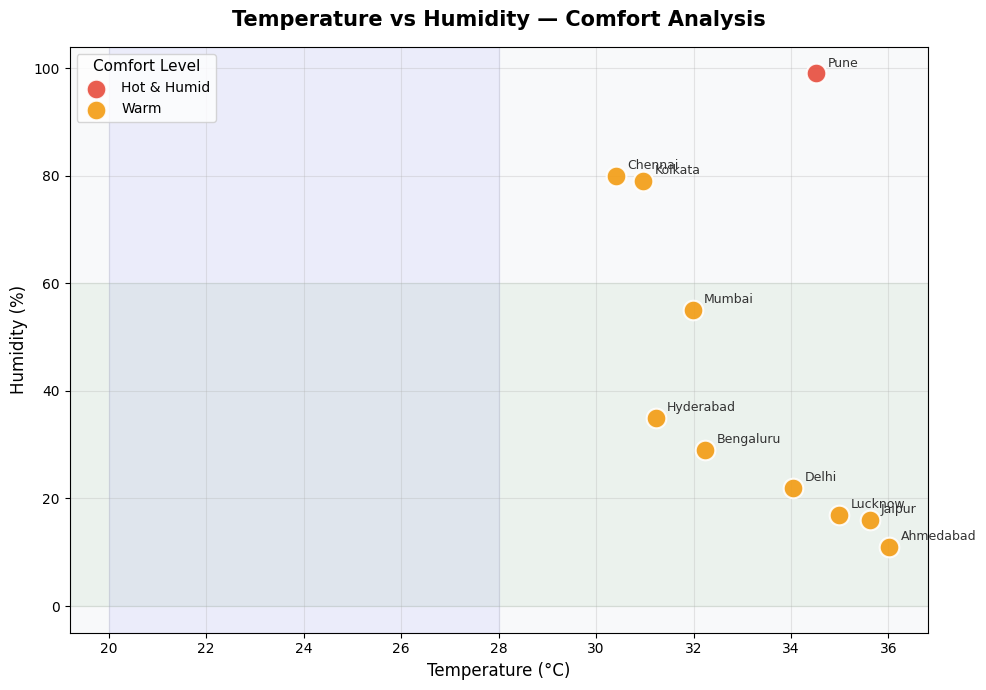

 Plot 4 saved!


In [10]:
comfort_colors = {'Cool': '#3498db', 'Comfortable': '#2ecc71', 'Warm': '#f39c12', 'Hot & Humid': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 7))

for comfort, grp in df.groupby('Comfort Level'):
    ax.scatter(grp['Temperature (°C)'], grp['Humidity (%)'],
               c=comfort_colors[comfort], s=200, label=comfort,
               edgecolors='white', linewidths=1.5, zorder=5, alpha=0.9)

for _, row in df.iterrows():
    ax.annotate(row['City'], (row['Temperature (°C)'], row['Humidity (%)']),
                textcoords='offset points', xytext=(8, 5), fontsize=9, color='#333')

# Comfort zone shading
ax.axhspan(0, 60, alpha=0.05, color='green', label='_nolegend_')
ax.axvspan(20, 28, alpha=0.05, color='blue', label='_nolegend_')

ax.set_title('Temperature vs Humidity — Comfort Analysis', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Humidity (%)', fontsize=12)
ax.legend(title='Comfort Level', fontsize=10, title_fontsize=11)
ax.grid(alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 4 saved!')

### Plot 5 — Wind Speed Comparison

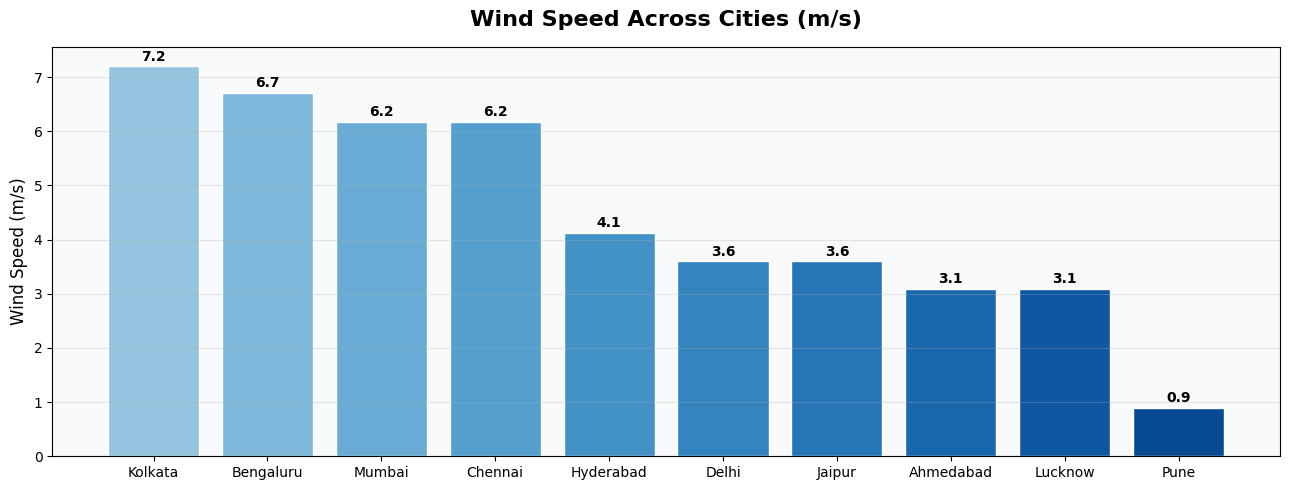

Plot 5 saved!


In [11]:
df_w = df.sort_values('Wind Speed (m/s)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
theta = np.linspace(0, 2*np.pi, 100)

# Wind speed as styled bar
bars = ax.bar(df_w['City'], df_w['Wind Speed (m/s)'],
              color=plt.cm.Blues(np.linspace(0.4, 0.9, len(df_w))),
              edgecolor='white', linewidth=1)

for bar, val in zip(bars, df_w['Wind Speed (m/s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Wind Speed Across Cities (m/s)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot5_wind.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 5 saved!')

### Plot 6 — Correlation Heatmap

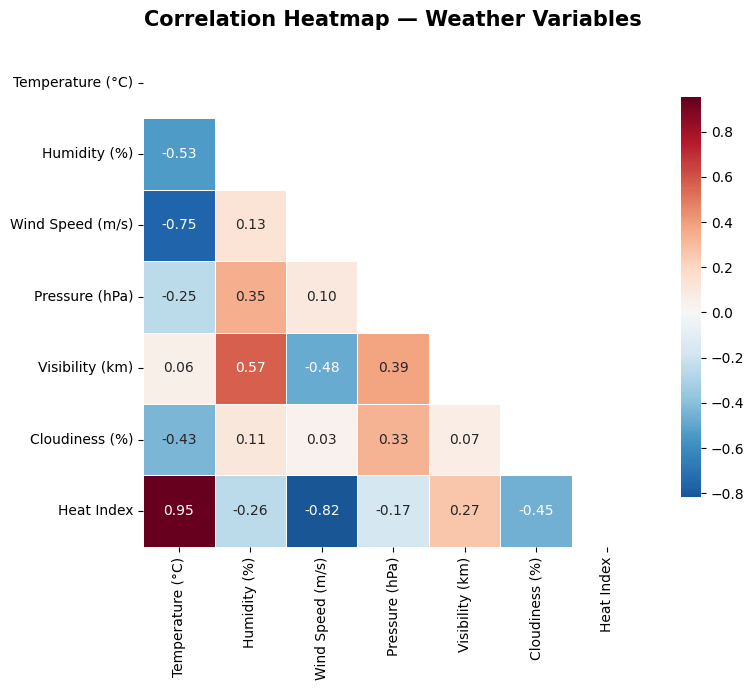

Plot 6 saved!


In [12]:
corr_cols = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
             'Pressure (hPa)', 'Visibility (km)', 'Cloudiness (%)', 'Heat Index']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Weather Variables', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 6 saved!')

### Plot 7 — Min/Max Temperature Range (Box Plot Style)

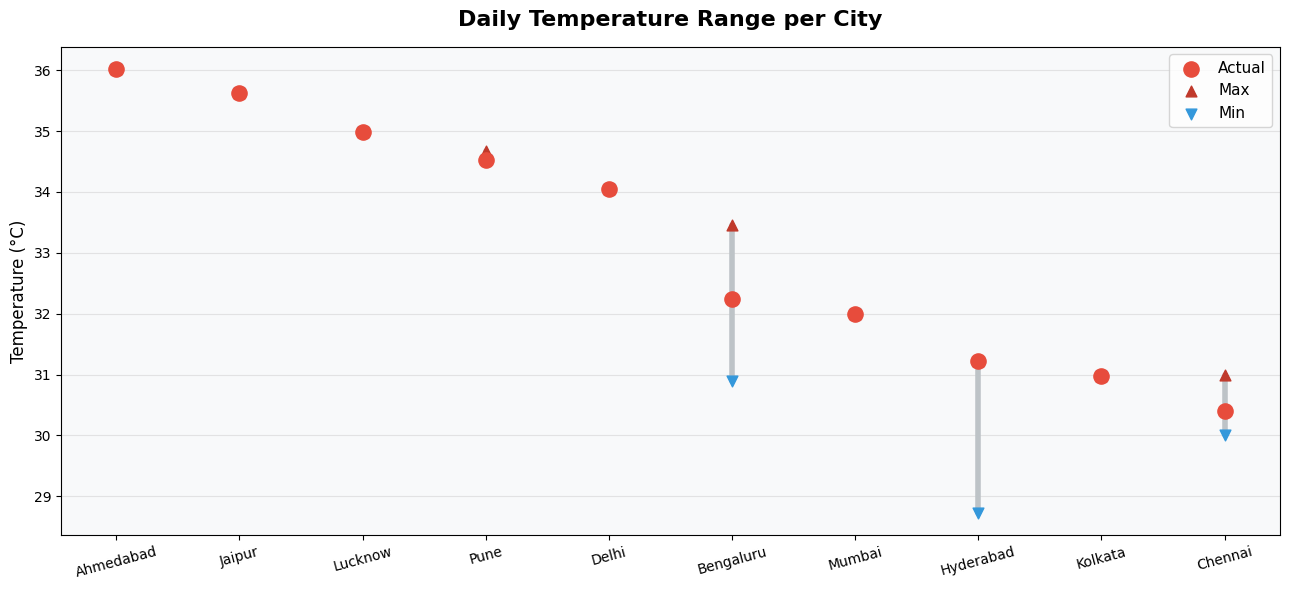

Plot 7 saved!


In [13]:
df_r = df.sort_values('Temperature (°C)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_r))

# Draw range bars
for i, (_, row) in enumerate(df_r.iterrows()):
    ax.plot([i, i], [row['Min Temp (°C)'], row['Max Temp (°C)']],
            color='#bdc3c7', linewidth=4, solid_capstyle='round', zorder=2)
    ax.scatter(i, row['Temperature (°C)'], color='#e74c3c', s=120, zorder=5, label='Actual' if i==0 else '')
    ax.scatter(i, row['Max Temp (°C)'], color='#c0392b', s=60, marker='^', zorder=4, label='Max' if i==0 else '')
    ax.scatter(i, row['Min Temp (°C)'], color='#3498db', s=60, marker='v', zorder=4, label='Min' if i==0 else '')

ax.set_xticks(x)
ax.set_xticklabels(df_r['City'], rotation=15)
ax.set_title('Daily Temperature Range per City', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('plot7_range.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 7 saved!')

### Plot 8 — Weather Condition Distribution (Pie Chart)

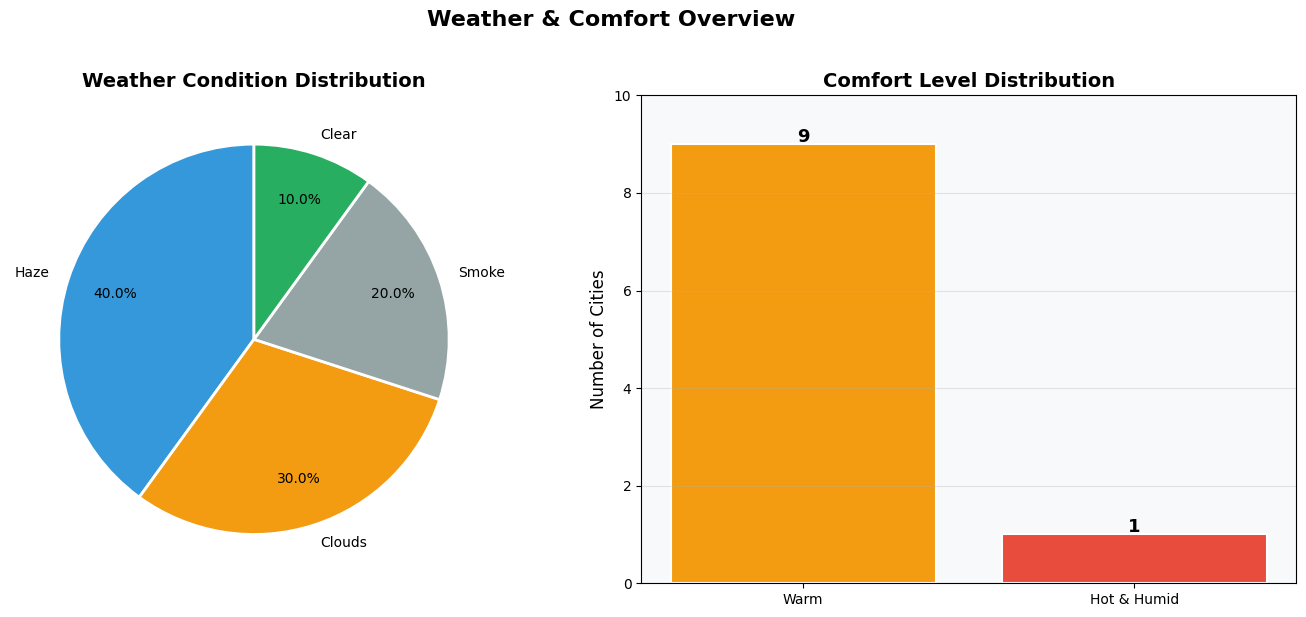

Plot 8 saved!


In [14]:
weather_counts = df['Weather'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_pie = ['#3498db', '#f39c12', '#95a5a6', '#27ae60', '#e74c3c']
ax1.pie(weather_counts.values, labels=weather_counts.index,
        autopct='%1.1f%%', colors=colors_pie[:len(weather_counts)],
        startangle=90, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Weather Condition Distribution', fontsize=14, fontweight='bold')

# Comfort level distribution
comfort_counts = df['Comfort Level'].value_counts()
colors_c = [comfort_colors.get(c, '#aaa') for c in comfort_counts.index]
bars = ax2.bar(comfort_counts.index, comfort_counts.values, color=colors_c, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, comfort_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha='center', fontsize=13, fontweight='bold')
ax2.set_title('Comfort Level Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Cities', fontsize=12)
ax2.set_ylim(0, comfort_counts.max() + 1)
ax2.set_facecolor('#f8f9fa')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Weather & Comfort Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot8_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 8 saved!')

### Plot 9 — Atmospheric Pressure & Visibility

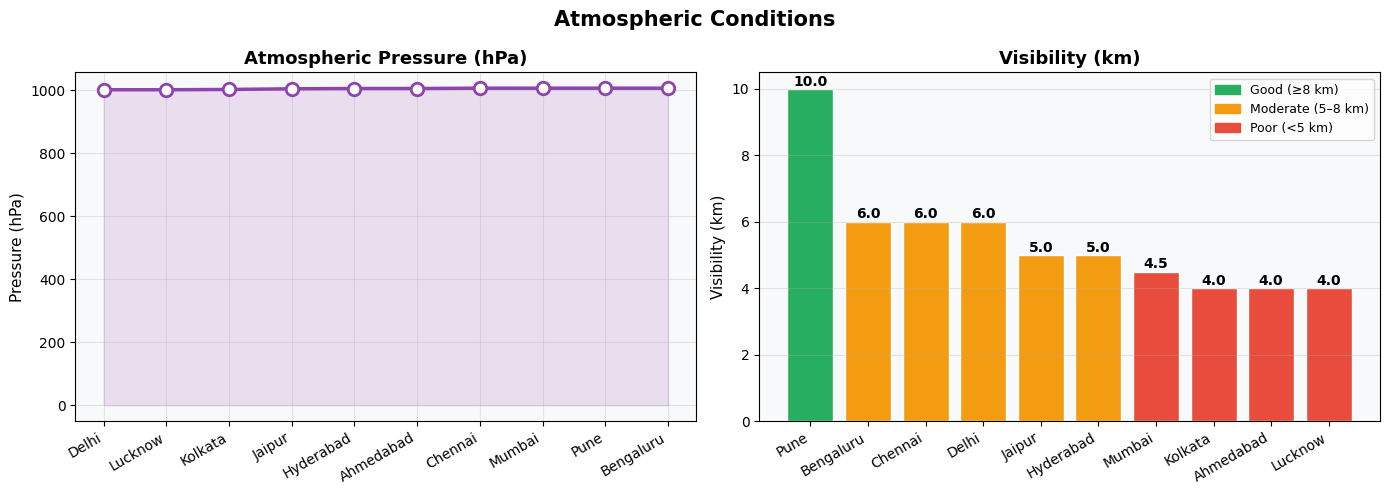

Plot 9 saved!


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_p = df.sort_values('Pressure (hPa)')
ax1.plot(df_p['City'], df_p['Pressure (hPa)'], 'o-', color='#8e44ad',
         linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(range(len(df_p)), df_p['Pressure (hPa)'], alpha=0.15, color='#8e44ad')
ax1.set_xticklabels(df_p['City'], rotation=30, ha='right')
ax1.set_xticks(range(len(df_p)))
ax1.set_title('Atmospheric Pressure (hPa)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Pressure (hPa)', fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_facecolor('#f8f9fa')

df_v = df.sort_values('Visibility (km)', ascending=False)
colors_v = ['#27ae60' if v >= 8 else '#f39c12' if v >= 5 else '#e74c3c' for v in df_v['Visibility (km)']]
bars = ax2.bar(df_v['City'], df_v['Visibility (km)'], color=colors_v, edgecolor='white')
for bar, val in zip(bars, df_v['Visibility (km)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Visibility (km)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Visibility (km)', fontsize=11)
ax2.set_xticklabels(df_v['City'], rotation=30, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('#f8f9fa')

# Legend for visibility
good = mpatches.Patch(color='#27ae60', label='Good (≥8 km)')
mod  = mpatches.Patch(color='#f39c12', label='Moderate (5–8 km)')
poor = mpatches.Patch(color='#e74c3c', label='Poor (<5 km)')
ax2.legend(handles=[good, mod, poor], fontsize=9)

plt.suptitle('Atmospheric Conditions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_atmosphere.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 9 saved!')

## Step 8: Final Summary & Insights

In [16]:
print('=' * 55)
print('        WEATHER ANALYSIS — FINAL INSIGHTS')
print('=' * 55)
print(f'Snapshot Time: {datetime.now().strftime("%B %d, %Y at %H:%M")}')
print()
print('TEMPERATURE')
print(f'  • Hottest:   {df.loc[df["Temperature (°C)"].idxmax(), "City"]} '
      f'({df["Temperature (°C)"].max():.1f}°C)')
print(f'  • Coolest:   {df.loc[df["Temperature (°C)"].idxmin(), "City"]} '
      f'({df["Temperature (°C)"].min():.1f}°C)')
print(f'  • Spread:    {df["Temperature (°C)"].max() - df["Temperature (°C)"].min():.1f}°C difference')
print()
print('HUMIDITY & COMFORT')
print(f'  • Most Humid:   {df.loc[df["Humidity (%)"].idxmax(), "City"]} ({df["Humidity (%)"].max():.0f}%)')
print(f'  • Least Humid:  {df.loc[df["Humidity (%)"].idxmin(), "City"]} ({df["Humidity (%)"].min():.0f}%)')
comfortable = df[df['Comfort Level'] == 'Comfortable']['City'].tolist()
print(f'  • Comfortable Cities: {", ".join(comfortable) if comfortable else "None"}')
print()
print('WIND & VISIBILITY')
print(f'  • Windiest:   {df.loc[df["Wind Speed (m/s)"].idxmax(), "City"]} ({df["Wind Speed (m/s)"].max():.1f} m/s)')
print(f'  • Best Visibility: {df.loc[df["Visibility (km)"].idxmax(), "City"]} ({df["Visibility (km)"].max():.1f} km)')
print()
print('KEY CORRELATIONS')
corr_th = df['Temperature (°C)'].corr(df['Humidity (%)'])
corr_tp = df['Temperature (°C)'].corr(df['Pressure (hPa)'])
print(f'  • Temp ↔ Humidity:  r = {corr_th:.2f}')
print(f'  • Temp ↔ Pressure:  r = {corr_tp:.2f}')
print()
print('Analysis Complete! All 9 plots saved.')
print('=' * 55)

        WEATHER ANALYSIS — FINAL INSIGHTS
Snapshot Time: April 21, 2026 at 19:20

TEMPERATURE
  • Hottest:   Ahmedabad (36.0°C)
  • Coolest:   Chennai (30.4°C)
  • Spread:    5.6°C difference

HUMIDITY & COMFORT
  • Most Humid:   Pune (99%)
  • Least Humid:  Ahmedabad (11%)
  • Comfortable Cities: None

WIND & VISIBILITY
  • Windiest:   Kolkata (7.2 m/s)
  • Best Visibility: Pune (10.0 km)

KEY CORRELATIONS
  • Temp ↔ Humidity:  r = -0.53
  • Temp ↔ Pressure:  r = -0.25

Analysis Complete! All 9 plots saved.


---
##  Save Dataset to CSV

In [17]:
df.to_csv('weather_india_cities.csv', index=False)
print(f'Dataset saved as weather_india_cities2.csv')
print(f'Rows: {len(df)} | Columns: {len(df.columns)}')
print(f'Columns: {list(df.columns)}')

Dataset saved as weather_india_cities2.csv
Rows: 10 | Columns: 18
Columns: ['City', 'Temperature (°C)', 'Feels Like (°C)', 'Min Temp (°C)', 'Max Temp (°C)', 'Humidity (%)', 'Pressure (hPa)', 'Wind Speed (m/s)', 'Wind Direction (°)', 'Visibility (km)', 'Cloudiness (%)', 'Weather', 'Description', 'Sunrise', 'Sunset', 'Fetched At', 'Heat Index', 'Comfort Level']
